In [1]:
from pathlib import Path
import os
import sys

# Make repo imports work even when the kernel starts inside a notebook subdirectory.
_repo_root = Path.cwd().resolve()
while _repo_root != _repo_root.parent and not (_repo_root / 'configs' / 'profiles.py').exists():
    _repo_root = _repo_root.parent
if not (_repo_root / 'configs' / 'profiles.py').exists():
    raise RuntimeError("Failed to locate MADRL_ESS repo root containing configs/profiles.py.")
_repo_root_str = str(_repo_root)
if _repo_root_str not in sys.path:
    sys.path.insert(0, _repo_root_str)
os.chdir(_repo_root)


# Compare

只读取 `notebooks/record/` 中已经存在的 canonical rollout 记录，不再触发训练、shared-data 构建或 MPC 重算。

In [2]:

import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from configs.experiment_config import COMPARE_SCHEME_ORDER, RECORD_SCHEME_CATEGORIES
from configs.profiles import project_root
from scripts.mainline_compare import build_compare_economic_table, build_compare_safety_table, compare_rollout_metrics
from scripts.plots.grid_notebook_plotting import (
    plot_battery_power_and_soc_comparison,
    plot_net_load_comparison,
    plot_power_balance_comparison,
    plot_price_prediction_comparison,
    plot_voltage_profile_comparison,
)
from scripts.utils.grid_notebook_workflow import assert_rollout_timestamp_alignment, load_rollout_record


Excel written to: D:\GithubProject\MADRL_ESS\notebooks\record\compare.xlsx


,controller,soc_mode,storage_charge_cost_total_eur,storage_discharge_revenue_total_eur,storage_profit_total_eur,storage_objective_total_eur,system_other_cost_eur,total_eur,soc_penalty_total,voltage_penalty_total,...,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur
0,Global MISOCP,continuous,881.787065,1421.710765,539.923700,-539.923700,1601.493344,-1061.569655,0.005283,0.007101,...,0.013556,0.057718,0.012438,0.052119,0,97.855133,25.723625,293.783783,45.641957,-538.368422
1,Local MPC + Perfect Forecast,continuous,809.305134,1391.394540,582.089407,-582.089407,NaN,NaN,0.005282,0.013142,...,0.014856,0.065087,0.013129,0.057139,154,170.433380,33.095352,312.749985,44.740487,NaN
2,Local MPC + LSTM Forecast,continuous,378.865735,604.496512,225.630777,-225.630777,NaN,NaN,0.005600,0.107171,...,0.017912,0.064629,0.011565,0.059479,121,183.569046,38.213551,322.802429,30.044293,NaN
3,ADMM MPC + LSTM Forecast,continuous,360.276817,589.380954,229.104137,-229.104137,NaN,NaN,0.005299,0.004058,...,0.015351,0.054800,0.010650,0.054353,39,101.157211,33.628344,281.227081,28.597237,NaN
4,MADRL + No Safety + LSTM Forecast,continuous,790.519210,1073.495073,282.975864,-282.975864,NaN,NaN,0.005176,0.000000,...,0.011640,0.058885,0.012883,0.049296,30,160.051239,30.162013,207.435623,41.226791,NaN
5,MADRL + Safety Penalty + LSTM Forecast,continuous,792.950118,822.989747,30.039629,-30.039629,NaN,NaN,0.003650,0.000000,...,0.010702,0.040036,0.012562,0.039562,13,119.154274,29.387093,156.147041,34.854585,NaN
6,MADRL + Safety Projection + LSTM Forecast,continuous,748.773809,1011.008654,262.234845,-262.234845,NaN,NaN,0.004067,0.000071,...,0.010783,0.055121,0.013046,0.054060,5,107.487099,27.251570,152.917068,40.002317,NaN


,controller,storage_discharge_revenue_total_eur,storage_charge_cost_total_eur,storage_profit_total_eur
0,Global MISOCP,1421.710765,881.787065,539.923700
1,Local MPC + Perfect Forecast,1391.394540,809.305134,582.089407
2,Local MPC + LSTM Forecast,604.496512,378.865735,225.630777
3,ADMM MPC + LSTM Forecast,589.380954,360.276817,229.104137
4,MADRL + No Safety + LSTM Forecast,1073.495073,790.519210,282.975864
5,MADRL + Safety Penalty + LSTM Forecast,822.989747,792.950118,30.039629
6,MADRL + Safety Projection + LSTM Forecast,1011.008654,748.773809,262.234845


,controller,voltage_violation_steps,voltage_violation_bus_points,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw
0,Global MISOCP,21,38,0.013556,0.057718,0.012438,0.052119,0,97.855133,25.723625,293.783783
1,Local MPC + Perfect Forecast,29,52,0.014856,0.065087,0.013129,0.057139,154,170.433380,33.095352,312.749985
2,Local MPC + LSTM Forecast,28,54,0.017912,0.064629,0.011565,0.059479,121,183.569046,38.213551,322.802429
3,ADMM MPC + LSTM Forecast,16,30,0.015351,0.054800,0.010650,0.054353,39,101.157211,33.628344,281.227081
4,MADRL + No Safety + LSTM Forecast,8,15,0.011640,0.058885,0.012883,0.049296,30,160.051239,30.162013,207.435623
5,MADRL + Safety Penalty + LSTM Forecast,0,0,0.010702,0.040036,0.012562,0.039562,13,119.154274,29.387093,156.147041
6,MADRL + Safety Projection + LSTM Forecast,3,5,0.010783,0.055121,0.013046,0.054060,5,107.487099,27.251570,152.917068


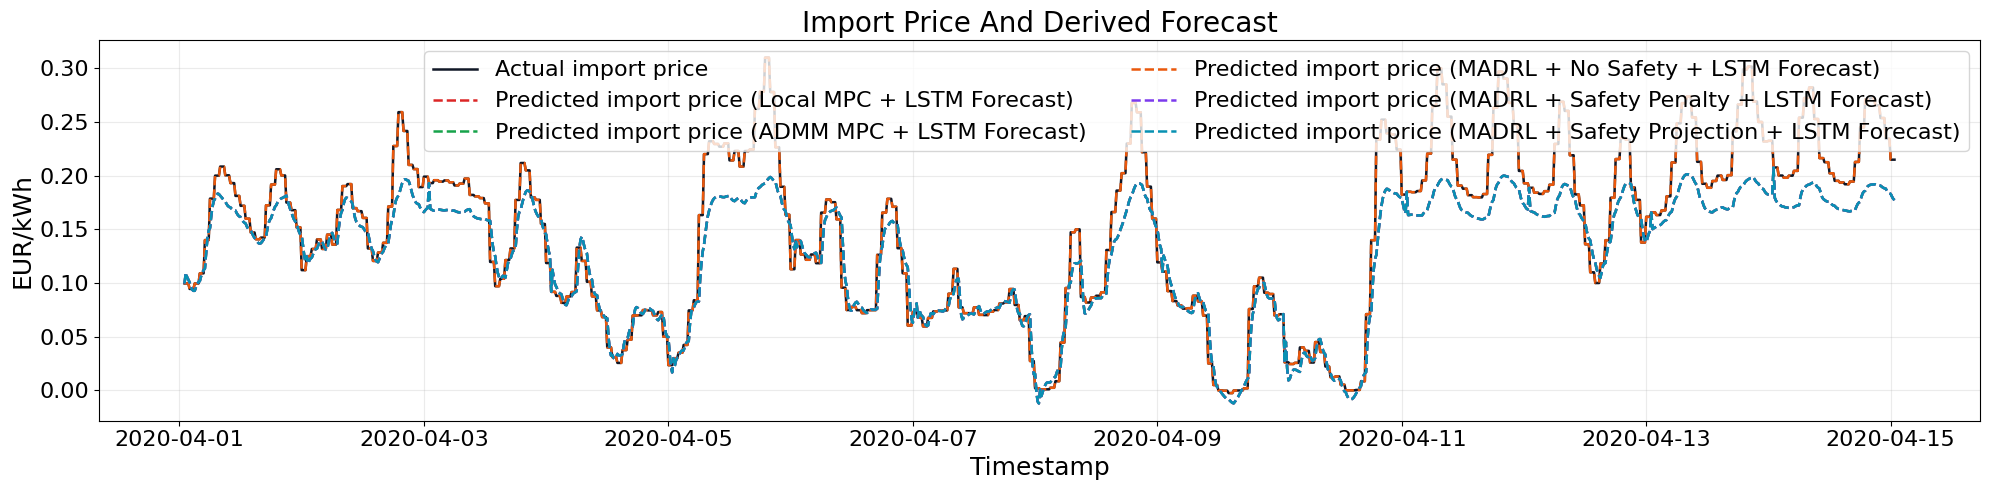

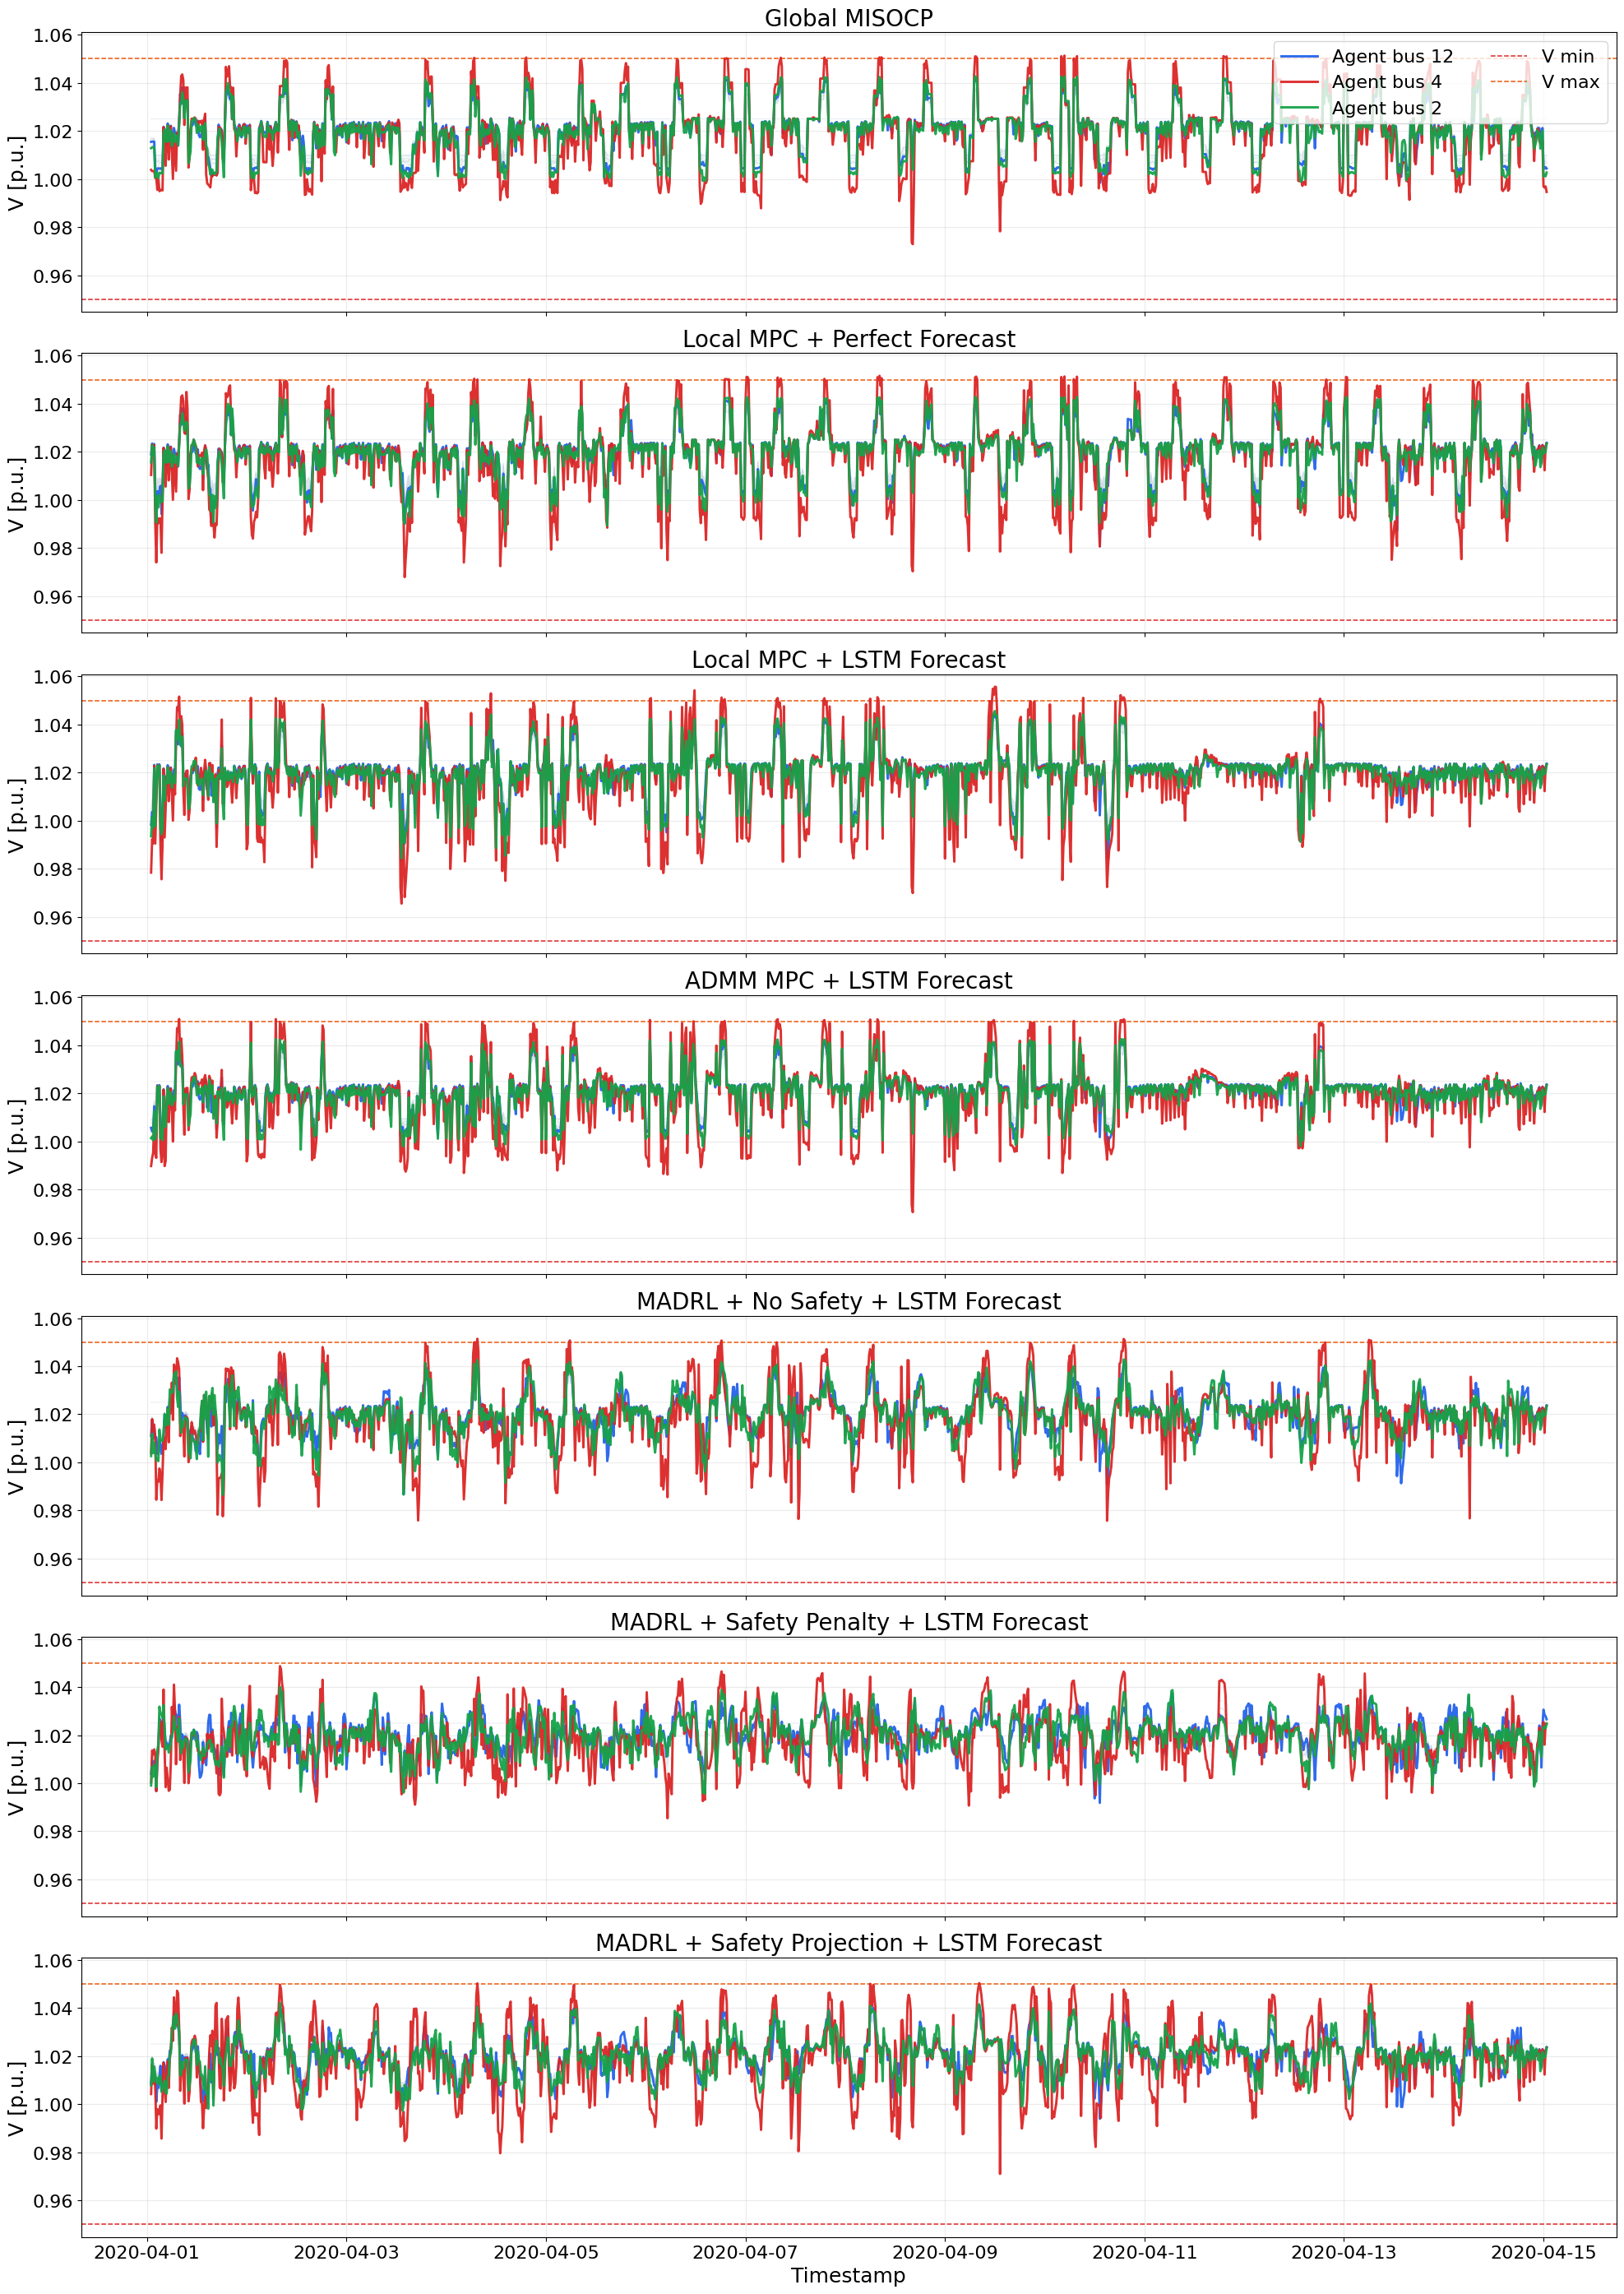

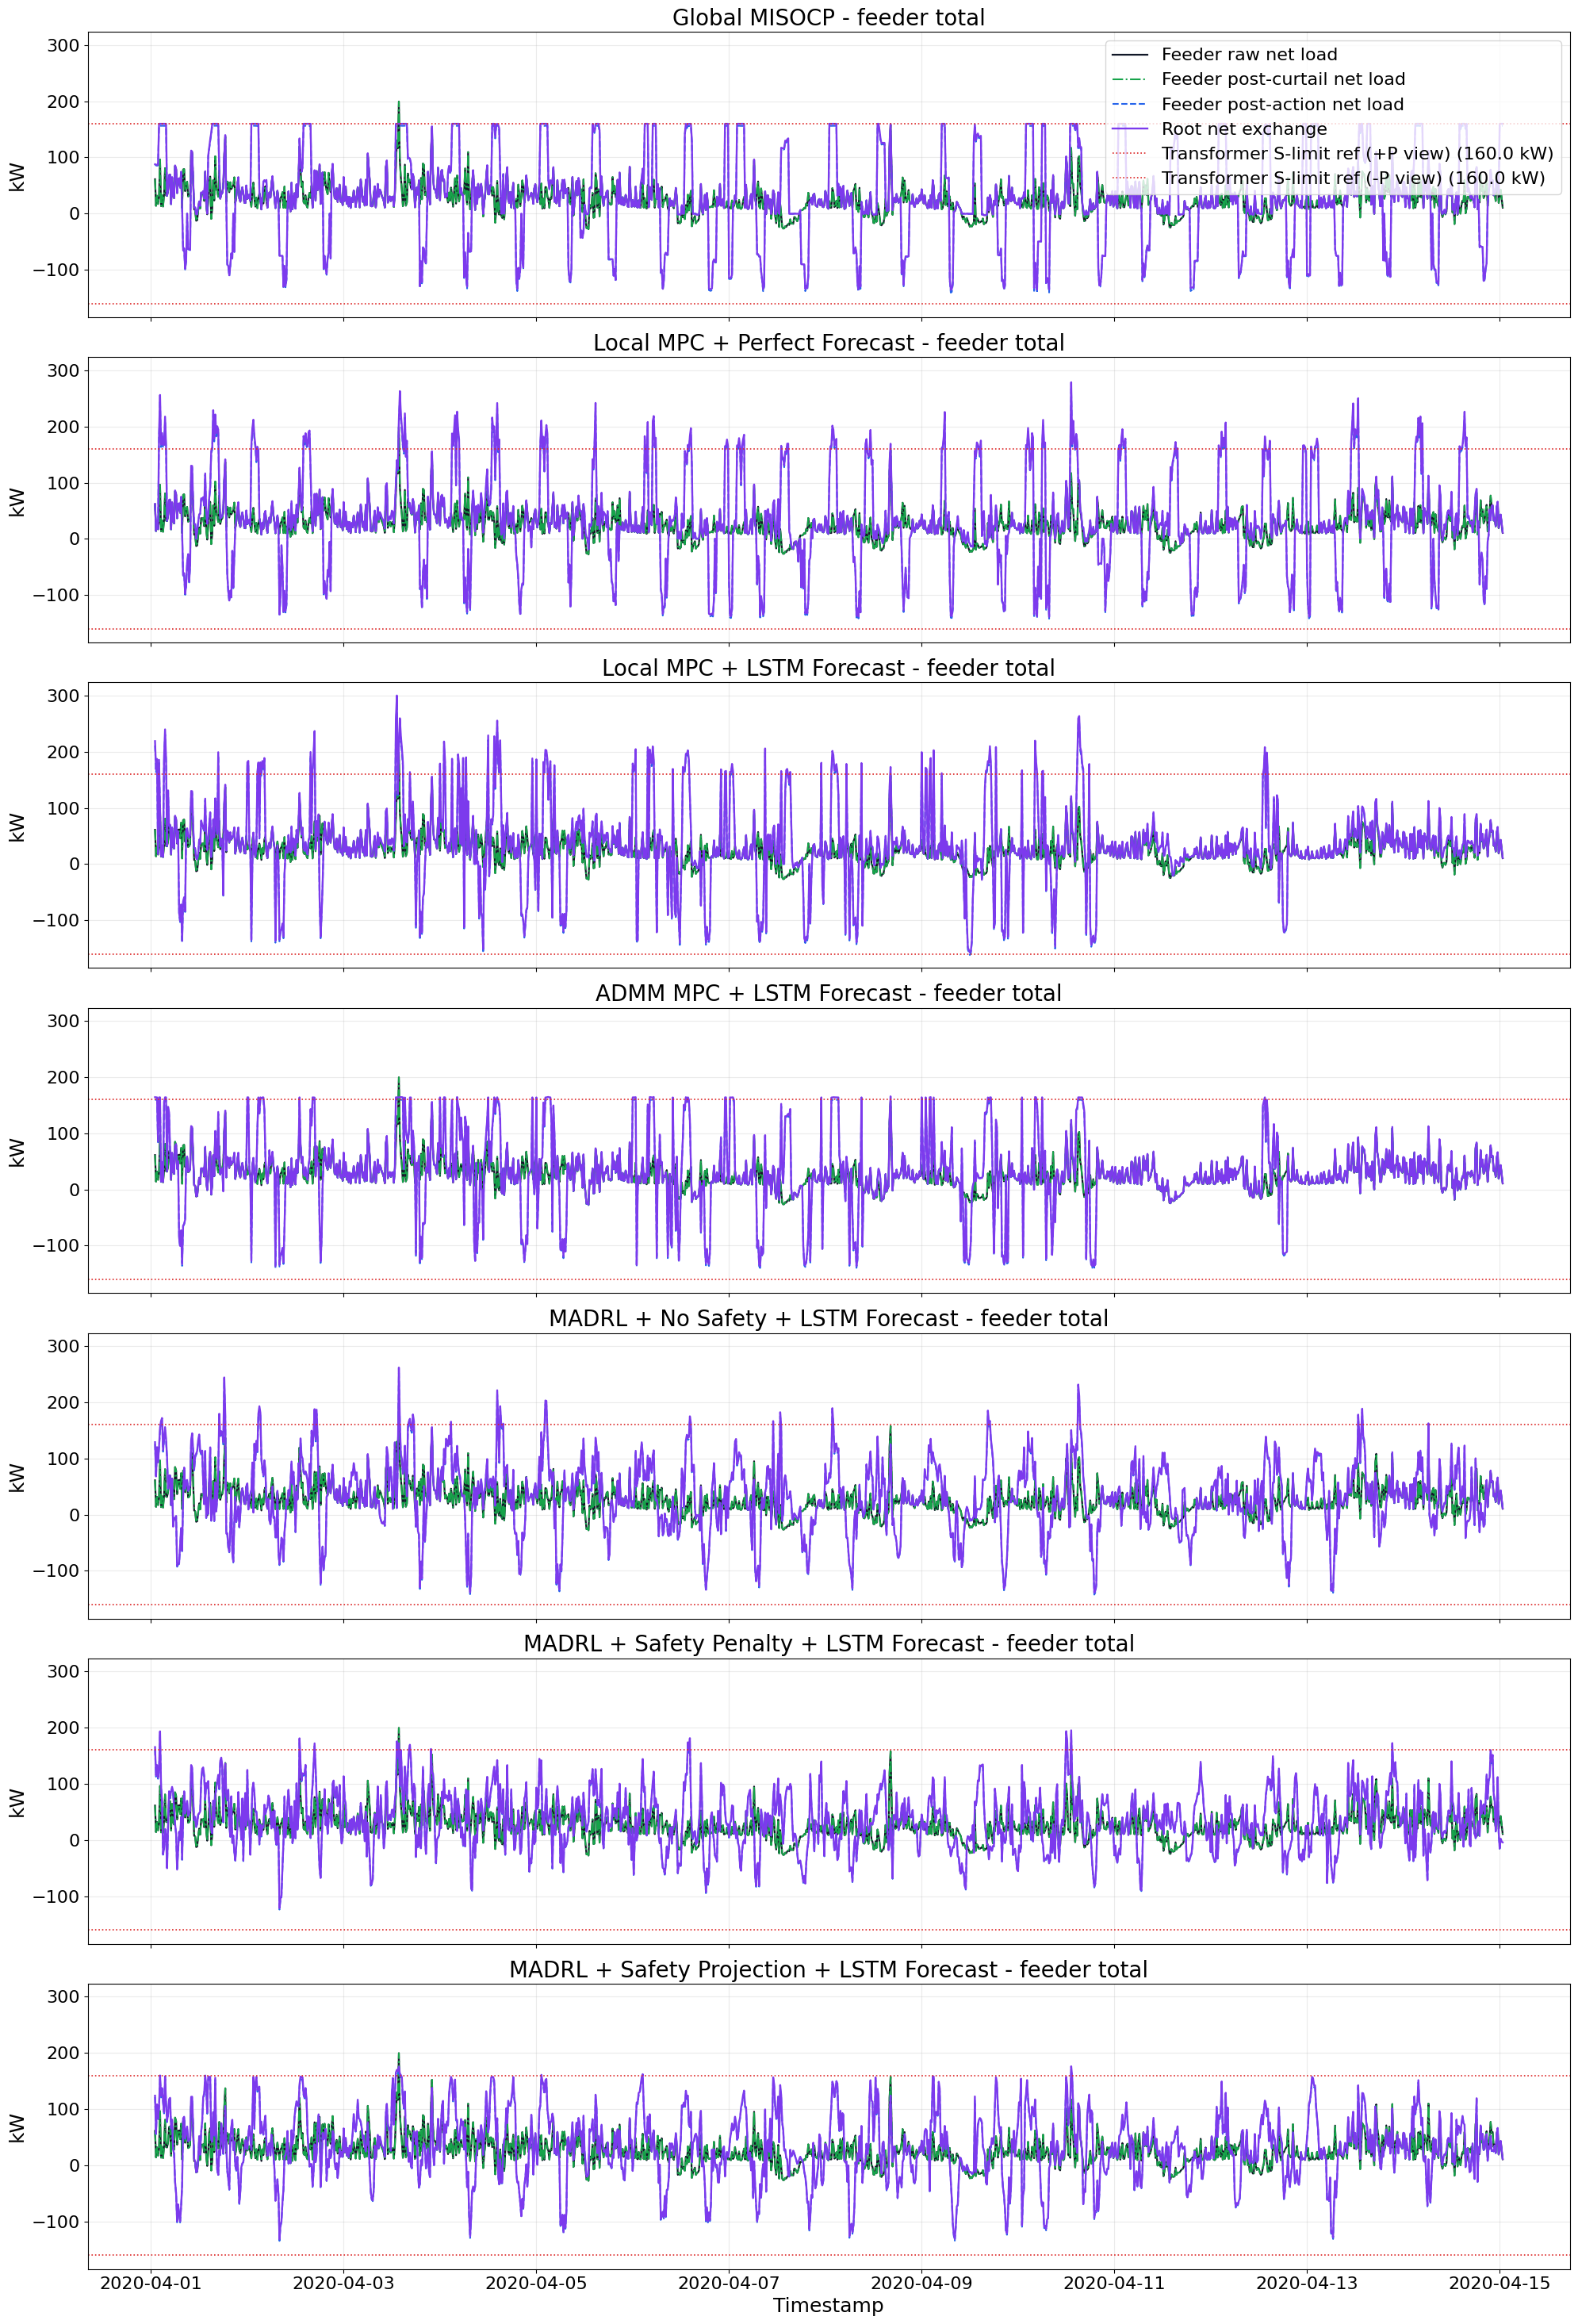

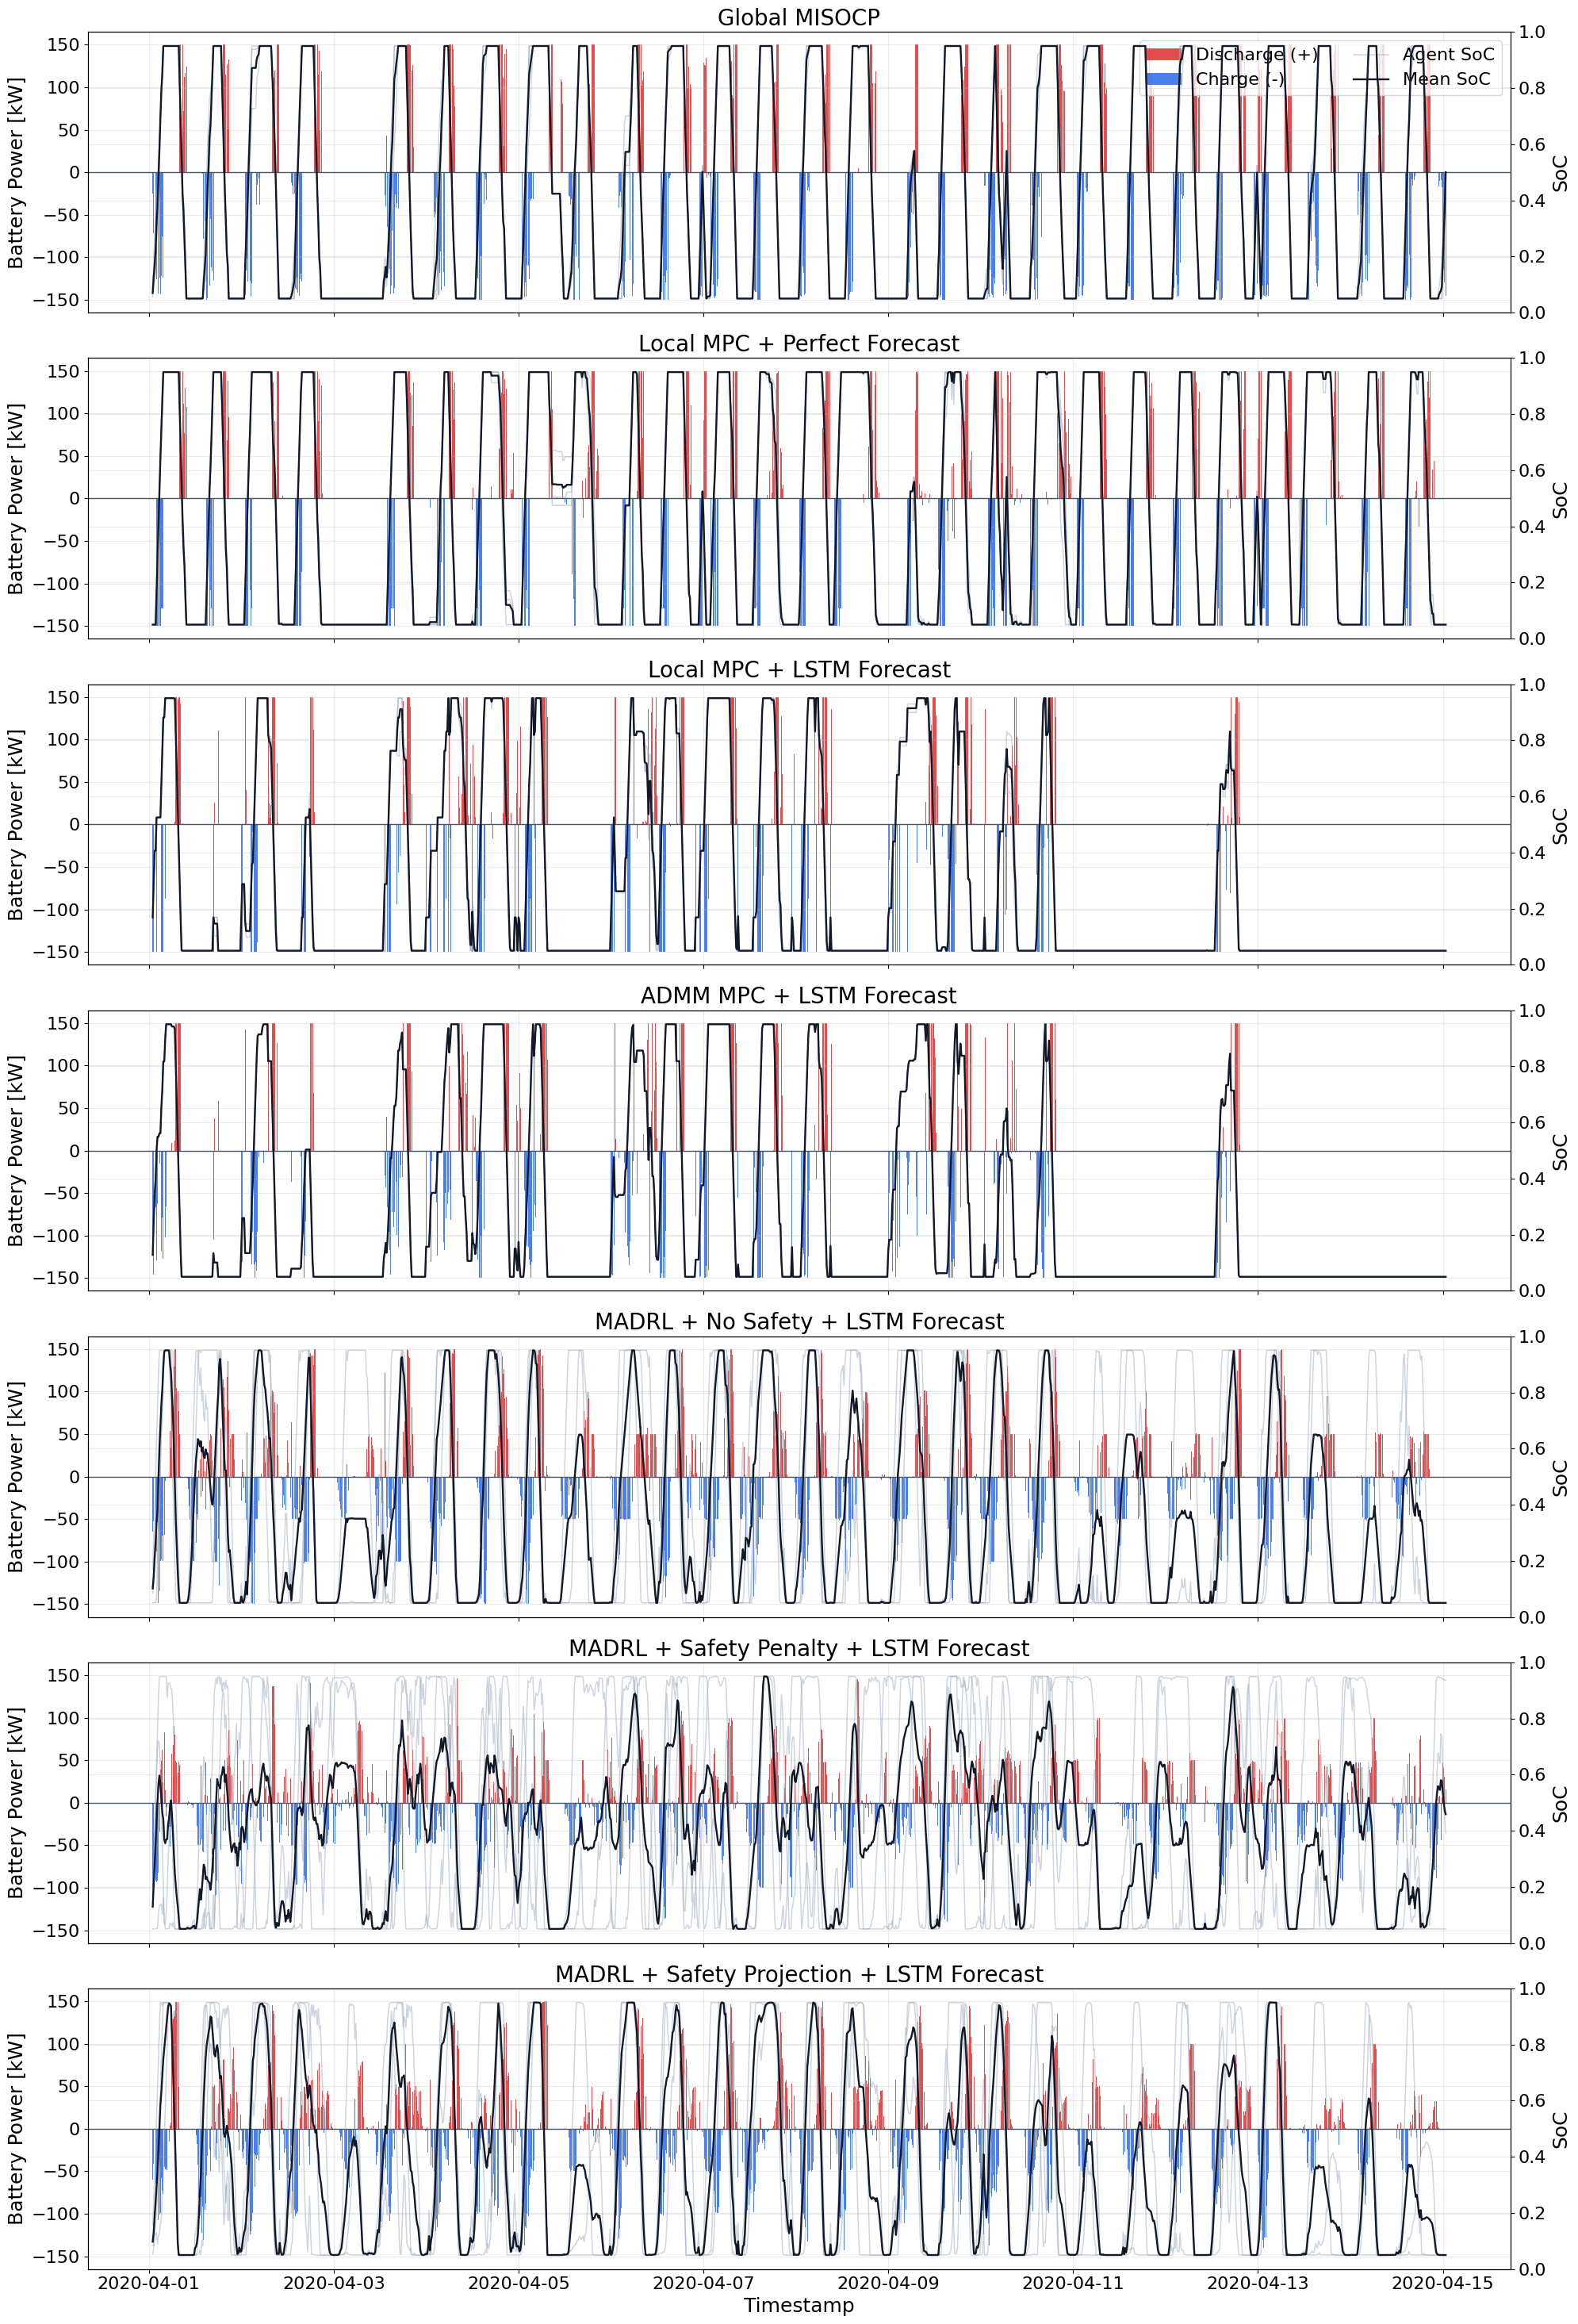

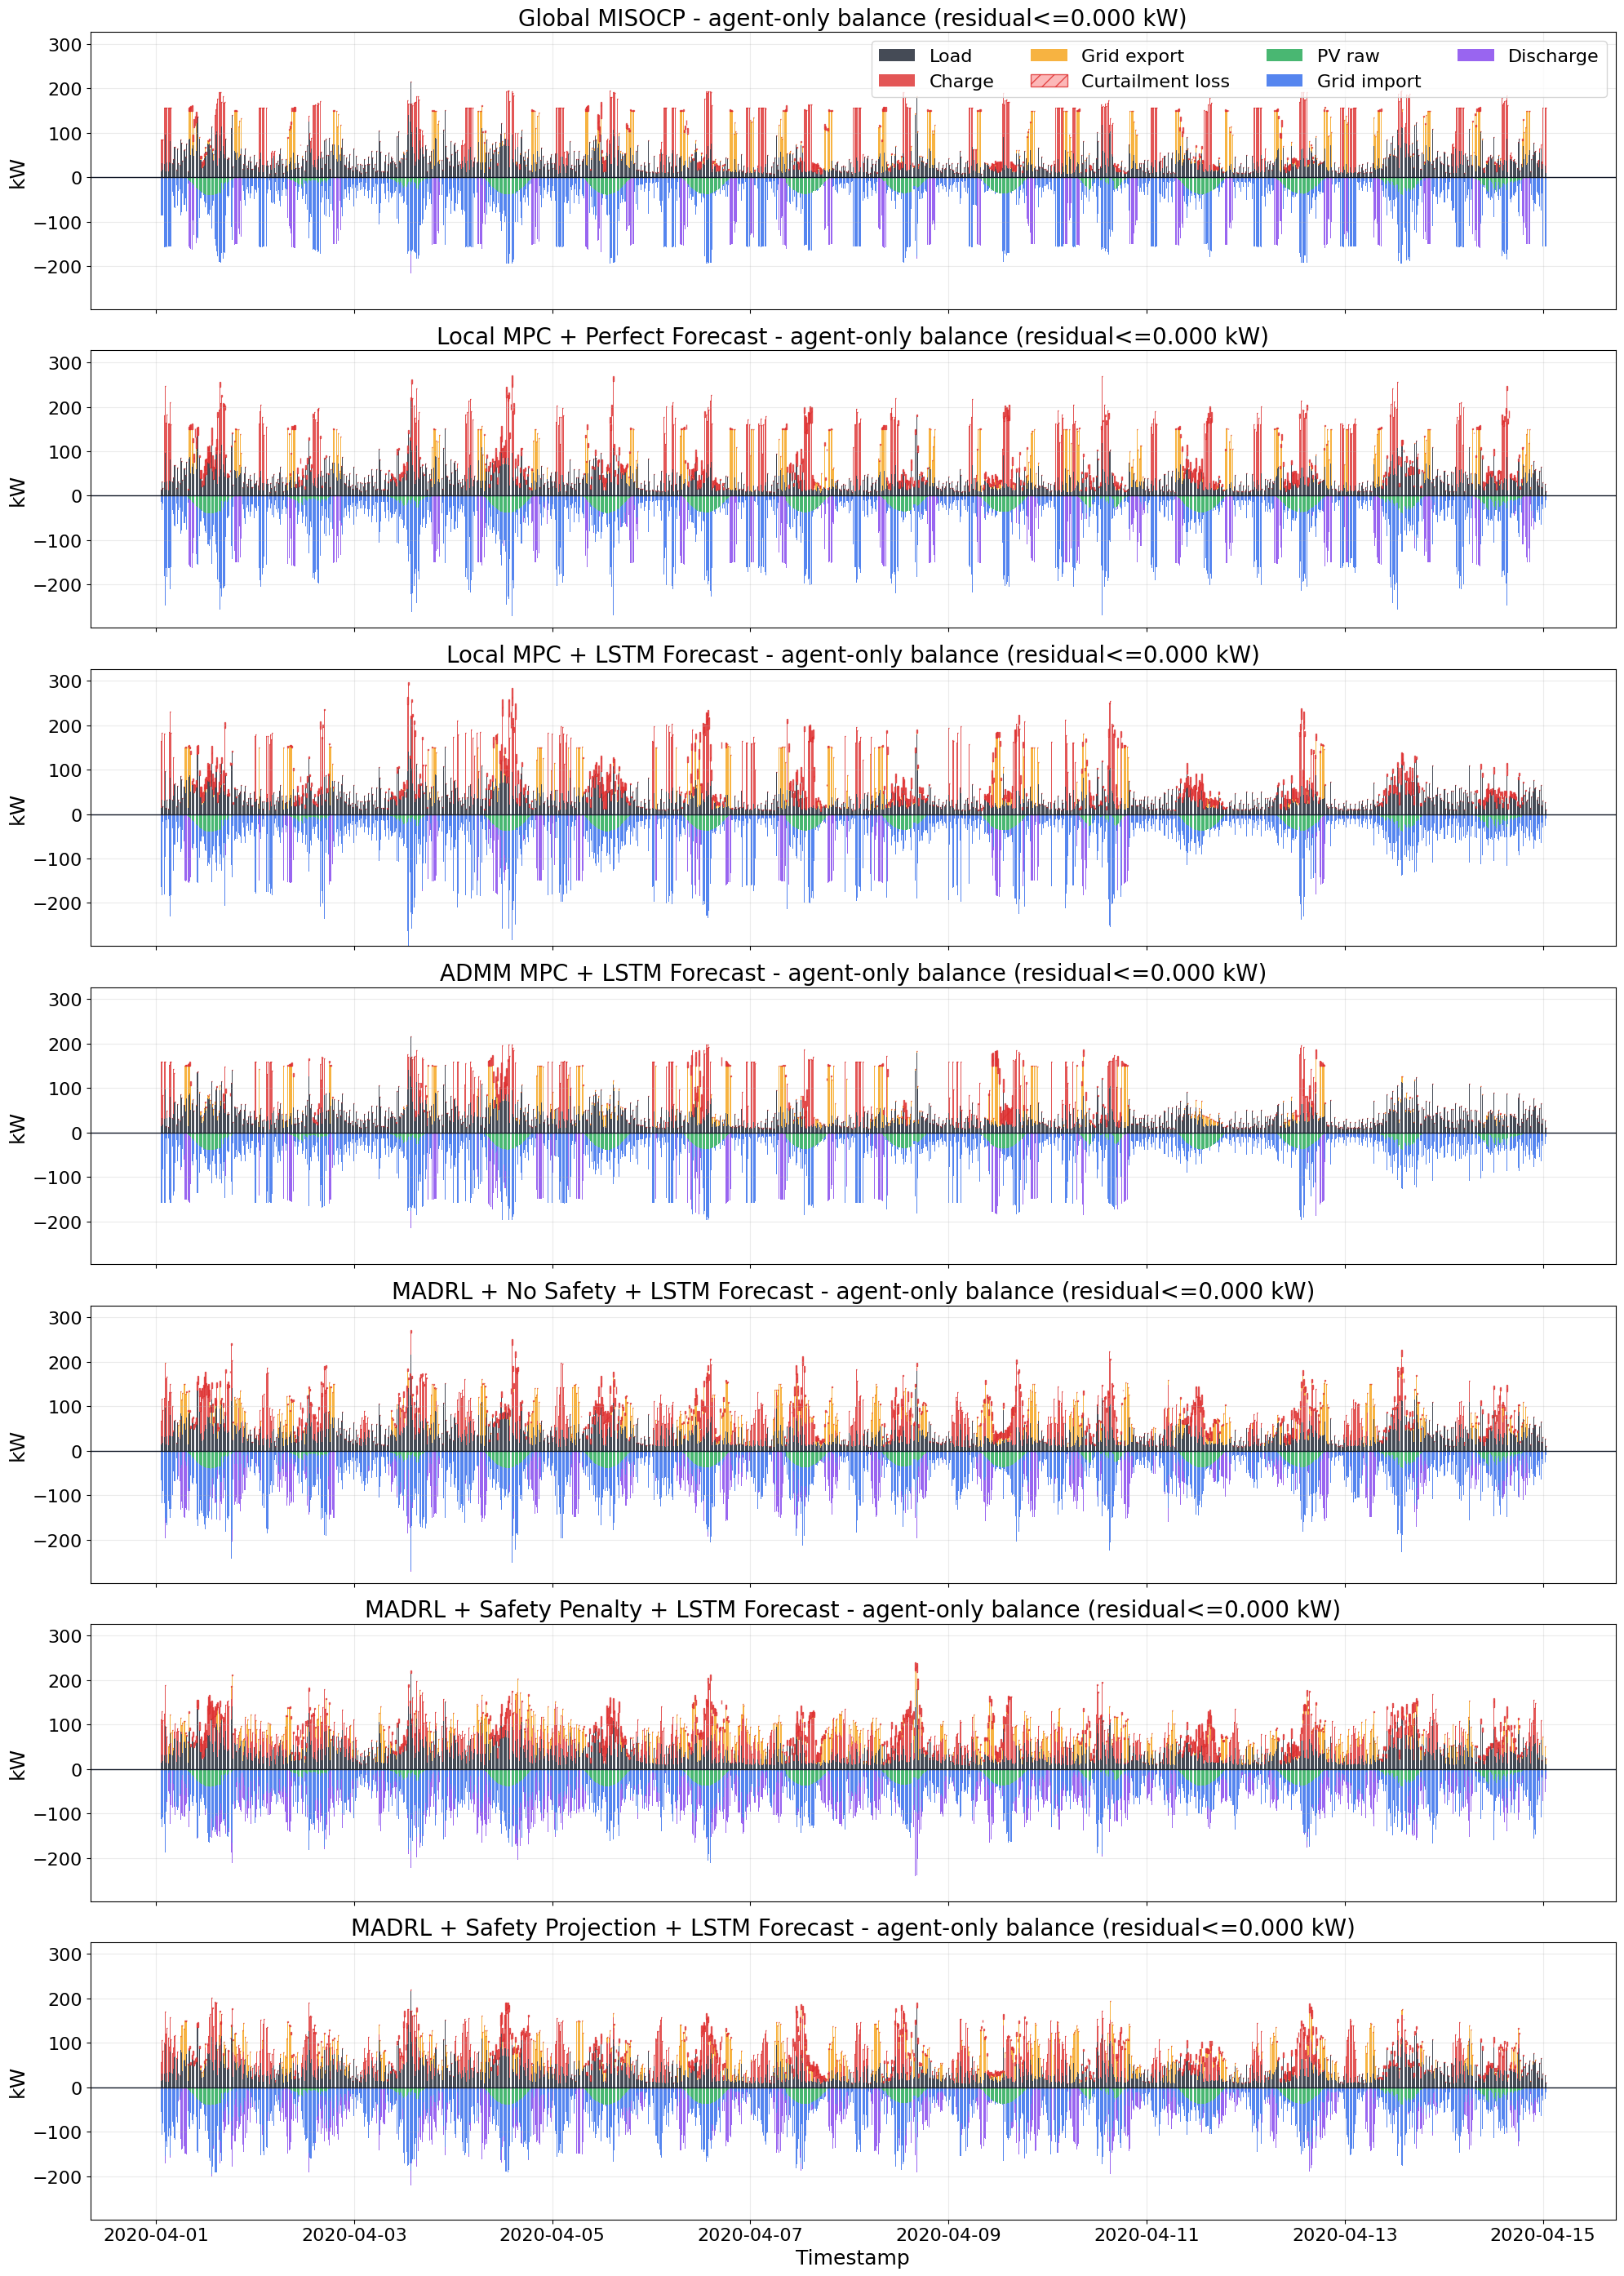

In [3]:

root = project_root()
rollouts = [load_rollout_record(category=RECORD_SCHEME_CATEGORIES[scheme_name], scheme_name=scheme_name, root=root) for scheme_name in COMPARE_SCHEME_ORDER]
assert_rollout_timestamp_alignment(*rollouts)
metrics_df = compare_rollout_metrics(*rollouts)
economic_table = build_compare_economic_table(metrics_df)
safety_table = build_compare_safety_table(metrics_df)

record_dir = root / 'notebooks' / 'record'
record_dir.mkdir(parents=True, exist_ok=True)
excel_path = record_dir / 'compare.xlsx'
used_sheet_names = set()

def excel_sheet_name(name):
    cleaned = ''.join('_' if char in '[]:*?/\\' else char for char in str(name))[:31]
    candidate = cleaned or 'sheet'
    suffix = 1
    while candidate in used_sheet_names:
        marker = f'_{suffix}'
        candidate = f'{cleaned[:31 - len(marker)]}{marker}'
        suffix += 1
    used_sheet_names.add(candidate)
    return candidate

def excel_ready_frame(frame):
    return frame.map(lambda value: value.isoformat() if getattr(value, 'tzinfo', None) is not None else value)

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    excel_ready_frame(metrics_df).to_excel(writer, sheet_name=excel_sheet_name('compare_metrics'), index=False)
    excel_ready_frame(economic_table).to_excel(writer, sheet_name=excel_sheet_name('economic_table'), index=False)
    excel_ready_frame(safety_table).to_excel(writer, sheet_name=excel_sheet_name('safety_table'), index=False)
    for scheme_name, rollout in zip(COMPARE_SCHEME_ORDER, rollouts):
        excel_ready_frame(pd.DataFrame([{'scheme_name': scheme_name, **rollout.meta}]).map(lambda value: json.dumps(value, ensure_ascii=False) if isinstance(value, (dict, list, tuple)) else value)).to_excel(writer, sheet_name=excel_sheet_name(f'{scheme_name}_meta'), index=False)
        excel_ready_frame(compare_rollout_metrics(rollout)).to_excel(writer, sheet_name=excel_sheet_name(f'{scheme_name}_metrics'), index=False)
        excel_ready_frame(rollout.summary).to_excel(writer, sheet_name=excel_sheet_name(f'{scheme_name}_summary'), index=False)
        excel_ready_frame(rollout.agent_df).to_excel(writer, sheet_name=excel_sheet_name(f'{scheme_name}_agent'), index=False)
        excel_ready_frame(rollout.step_df).to_excel(writer, sheet_name=excel_sheet_name(f'{scheme_name}_step'), index=False)
        excel_ready_frame(rollout.grid_df).to_excel(writer, sheet_name=excel_sheet_name(f'{scheme_name}_grid'), index=False)

print(f'Excel written to: {excel_path}')

display(metrics_df)
display(economic_table)
display(safety_table)

plot_price_prediction_comparison(*rollouts)
plt.show()
plot_voltage_profile_comparison(*rollouts)
plt.show()
plot_net_load_comparison(*rollouts)
plt.show()
plot_battery_power_and_soc_comparison(*rollouts)
plt.show()
plot_power_balance_comparison(*rollouts)
plt.show()
